## Problema - Crecimiento de Suscriptores en una Plataforma Digital

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.


In [ ]:
# @title Ingrese datos
nombre_estudiante = "Giovanni Alejandro Castillo Buitrago"# @param {"type":"string"}
carnet = 1000115755 # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Una plataforma de streaming quiere modelar cuántos suscriptores nuevos se registran cada mes. Se sabe que:

- En el mes 0 no hubo nuevos suscriptores (T(0) = 0).
- En el mes 1 se registró 1 nuevo suscriptor (T(1) = 1).
- A partir del mes 2, los nuevos suscriptores de un mes son la suma de los nuevos suscriptores de los dos meses anteriores, ya que se combinan los referidos generados el mes inmediatamente anterior con las recomendaciones que se acumularon dos meses atrás.

Esto se modela con la relación de recurrencia:

T(n) = 0, si n = 0  
T(n) = 1, si n = 1  
T(n) = T(n-1) + T(n-2), si n ≥ 2

El objetivo es calcular T(n) para cualquier mes n, evitando el recálculo repetido de subproblemas mediante memoizacion.


## 2) Requerimientos **[2 pts]**

- Funcionales 
    - El sistema debe recibir como entrada un número entero n (mes) mayor o igual a 0.
    - El sistema debe calcular T(n) aplicando la relación de recurrencia definida.
    - El sistema debe usar memoización para no recalcular valores de T ya calculados previamente.
    - El sistema debe devolver el número de nuevos suscriptores correspondiente al mes n.

- No funcionales 
    - El algoritmo debe tener complejidad de tiempo O(n) gracias a la memoización.
    - El código debe ser legible y estar comentado.
    - El sistema debe manejar correctamente los casos base (n = 0 y n = 1) sin errores.
    - La solución debe poder ejecutarse para valores de n moderadamente grandes sin agotar la pila de recursión de forma innecesaria.


## 3) Historias de usuario **[2 pts]**

Historia 1
Como analista de la plataforma, quiero ingresar el número de un mes n, para conocer cuántos nuevos suscriptores se registraron ese mes.  
*Criterios de aceptación:*
- Dado un valor de n = 0, el sistema retorna 0.
- Dado un valor de n = 1, el sistema retorna 1.

Historia 2
Como analista de la plataforma, quiero que el cálculo de meses ya consultados sea instantáneo, para no esperar tiempos de respuesta innecesarios.  
*Criterios de aceptación:*
- Si se consulta un mes n cuyo valor ya fue calculado, el sistema lo reutiliza en lugar de recalcularlo.

Historia 3 
Como desarrollador, quiero que la función use memoización, para que la complejidad del algoritmo sea lineal y no exponencial.  
*Criterios de aceptación:*
- Para n = 30, el algoritmo debe ejecutarse sin el crecimiento exponencial de llamadas propio de la recursión simple.

Historia 4 
Como analista de la plataforma, quiero validar que el algoritmo entrega los valores correctos para los primeros meses, para confiar en los resultados antes de usarlos en reportes.  
*Criterios de aceptación:*
- La secuencia generada para n = 0 hasta n = 6 corresponde a 0, 1, 1, 2, 3, 5, 8.


## 4) Diagramas de flujo **[5 pts]**
Incluye el diagrama que muestre el proceso general

Adjunta imagen y descríbelo claramente.

El diagrama siguiente resume el proceso: se valida si n es un caso base (0 o 1); si no lo es, se valida si el valor ya existe en la memoria (memo); si existe, se retorna directamente; si no existe, se calculan T(n-1) y T(n-2) de forma recursiva, se suman, se guardan en memo y se retorna el resultado.


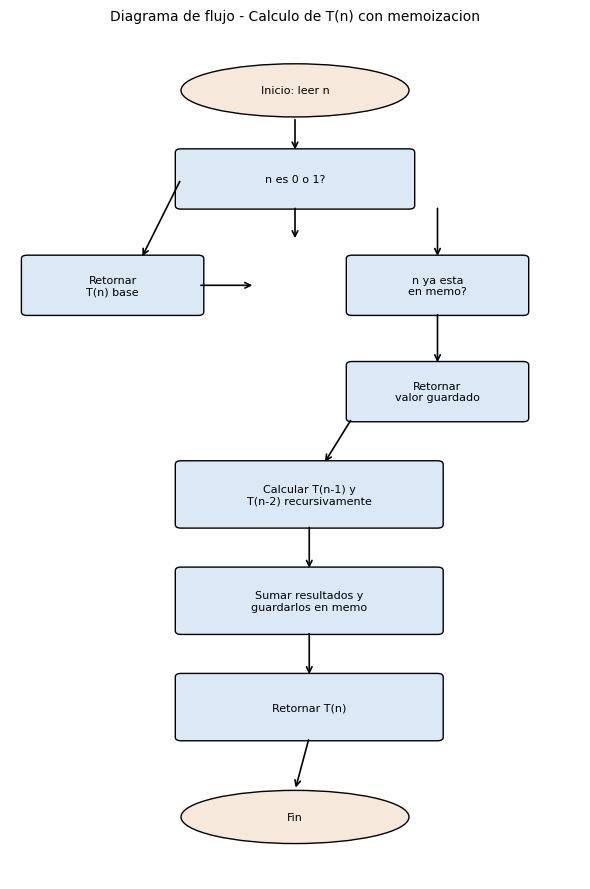


### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación
- Función T[n]
- Mejor y peor caso con gráfica

- Justificacion

Sin memoizacion, la recursión T(n) = T(n-1) + T(n-2) genera un arbol de llamadas que se repite muchas veces (los mismos subproblemas se recalculan una y otra vez), lo que produce una complejidad exponencial, aproximadamente O(2^n).

Con memoizacion, cada valor de T(k) para k entre 0 y n se calcula una única vez y se guarda en una estructura (memo). Las llamadas posteriores que necesiten ese valor lo obtienen en tiempo O(1). Como existen n+1 subproblemas distintos (T(0), T(1), ..., T(n)) y cada uno se resuelve en tiempo constante (una suma y un acceso a memo), la complejidad total en tiempo es O(n). La complejidad en espacio también es O(n), por el arreglo memo y por la pila de llamadas recursivas.

- Función T[n]

T(n) = 0, si n = 0  
T(n) = 1, si n = 1  
T(n) = T(n-1) + T(n-2), si n ≥ 2

- Mejor y peor caso

A diferencia de algoritmos como la busqueda o el ordenamiento, este algoritmo no depende de los datos de entrada sino unicamente del valor de n: siempre recorre los mismos n subproblemas sin importar el "orden" o "distribución" de nada. Por eso el mejor caso y el peor caso coinciden: ambos son O(n) en tiempo y O(n) en espacio. La única diferencia notable es cuando un valor ya fue calculado previamente y sigue en memo dentro de la misma ejecucion, donde la consulta puntual es O(1), pero el llenado completo de memo para un n nuevo siempre exige O(n).


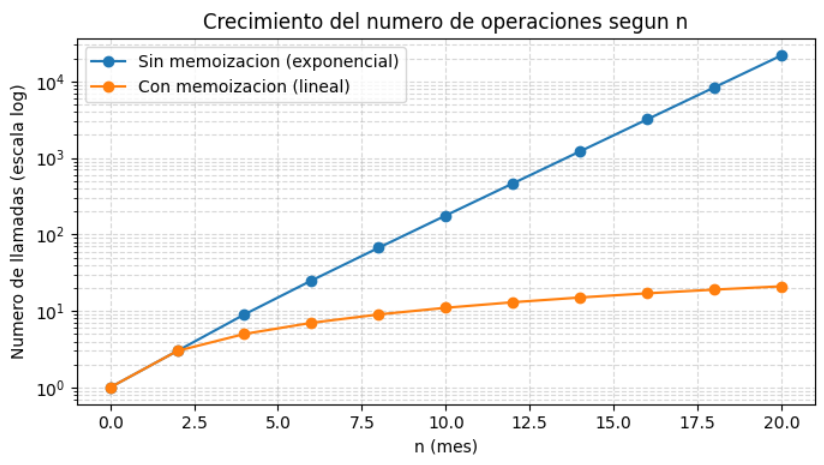


## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [ ]:
# Escribe tu codigo aqui.

def calcularSuscriptores(p_n, p_memo):
    
    if p_n == 0:
        return 0
    if p_n == 1:
        return 1
    if p_memo[p_n] != -1:
        return p_memo[p_n]
    resultado = calcularSuscriptores(p_n - 1, p_memo) + calcularSuscriptores(p_n - 2, p_memo)
    p_memo[p_n] = resultado

    return resultado


def nuevosSuscriptoresMes(p_n):
    memo = [-1] * (p_n + 1)
    return calcularSuscriptores(p_n, memo)


# Ejemplo de uso
mesConsultado = 10
resultado = nuevosSuscriptoresMes(mesConsultado)
print("Nuevos suscriptores en el mes", mesConsultado, "=", resultado)


Nuevos suscriptores en el mes 10 -> 55


## 7) Tests aplicados **[15 pts]**


In [ ]:
# Tests aplicados

assert nuevosSuscriptoresMes(0) == 0
assert nuevosSuscriptoresMes(1) == 1
assert nuevosSuscriptoresMes(2) == 1
assert nuevosSuscriptoresMes(3) == 2
assert nuevosSuscriptoresMes(4) == 3
assert nuevosSuscriptoresMes(5) == 5
assert nuevosSuscriptoresMes(6) == 8
assert nuevosSuscriptoresMes(10) == 55

print("Todos los tests pasaron correctamente.")
